<a href="https://www.kaggle.com/code/omborse771924/ev-adoption-behavior-analysis-88-accuracy?scriptVersionId=338629595" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/itzzomkar/ev-adoption-behavior-and-range-anxiety/EV_Adoption_and_Range_Anxiety_Dataset.csv


## Loading Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/itzzomkar/ev-adoption-behavior-and-range-anxiety/EV_Adoption_and_Range_Anxiety_Dataset.csv')

In [3]:
df.head()

,Buyer_ID,Age,Gender,Annual_Income_USD,City_Type,Daily_Commute_km,Number_of_Cars_Owned,Current_Car_Type,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Home_Charging_Possible,Environmental_Concern_Level,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,EV00001,56,Male,44906.0,Rural,18.1,1,Truck,1,0,Yes,4.0,Yes,Low,No
1,EV00002,36,Male,88754.0,Rural,5.0,1,SUV,2,3,Yes,1.0,Yes,Low,No
2,EV00003,42,Male,155958.0,Urban,32.2,2,Sedan,14,3,No,2.0,Yes,Medium,Yes
3,EV00004,31,Male,37059.0,Rural,89.9,1,Sedan,2,1,Yes,4.0,No,Low,No
4,EV00005,48,Female,48552.0,Rural,71.0,1,Sedan,2,0,Yes,3.0,Yes,Low,No


In [4]:
df.tail()

,Buyer_ID,Age,Gender,Annual_Income_USD,City_Type,Daily_Commute_km,Number_of_Cars_Owned,Current_Car_Type,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Home_Charging_Possible,Environmental_Concern_Level,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
9995,EV09996,50,Male,61279.0,Urban,71.4,1,Sedan,8,3,No,3.0,Yes,Medium,No
9996,EV09997,34,Male,108208.0,Urban,48.0,2,Hatchback,9,7,No,5.0,No,Low,No
9997,EV09998,60,Female,97743.0,Urban,9.0,2,Sedan,10,3,No,5.0,Yes,Low,No
9998,EV09999,31,Female,103628.0,Urban,81.8,2,SUV,10,10,Yes,1.0,Yes,Low,No
9999,EV10000,64,Other,59052.0,Suburban,24.0,2,Hatchback,1,9,Yes,5.0,Yes,Low,No


In [5]:
df.info

<bound method DataFrame.info of      Buyer_ID  Age  Gender  Annual_Income_USD City_Type  Daily_Commute_km  \
0     EV00001   56    Male            44906.0     Rural              18.1   
1     EV00002   36    Male            88754.0     Rural               5.0   
2     EV00003   42    Male           155958.0     Urban              32.2   
3     EV00004   31    Male            37059.0     Rural              89.9   
4     EV00005   48  Female            48552.0     Rural              71.0   
...       ...  ...     ...                ...       ...               ...   
9995  EV09996   50    Male            61279.0     Urban              71.4   
9996  EV09997   34    Male           108208.0     Urban              48.0   
9997  EV09998   60  Female            97743.0     Urban               9.0   
9998  EV09999   31  Female           103628.0     Urban              81.8   
9999  EV10000   64   Other            59052.0  Suburban              24.0   

      Number_of_Cars_Owned Current_Car_Type

In [6]:
df.describe()

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level
count,10000.000000,9822.000000,9819.000000,10000.000000,10000.000000,10000.000000,9816.000000
mean,46.936200,85378.485848,41.105418,1.859900,5.346900,7.458200,2.982783
std,12.945968,32838.684167,23.351276,0.855421,4.049074,5.259374,1.413784
min,25.000000,30000.000000,5.000000,1.000000,0.000000,0.000000,1.000000
25%,36.000000,61369.500000,23.250000,1.000000,2.000000,3.000000,2.000000
50%,47.000000,84708.000000,40.200000,2.000000,5.000000,6.000000,3.000000
75%,58.000000,107383.250000,57.000000,2.000000,8.000000,11.000000,4.000000
max,69.000000,223345.000000,135.500000,4.000000,14.000000,19.000000,5.000000


In [7]:
df.isnull

<bound method DataFrame.isnull of      Buyer_ID  Age  Gender  Annual_Income_USD City_Type  Daily_Commute_km  \
0     EV00001   56    Male            44906.0     Rural              18.1   
1     EV00002   36    Male            88754.0     Rural               5.0   
2     EV00003   42    Male           155958.0     Urban              32.2   
3     EV00004   31    Male            37059.0     Rural              89.9   
4     EV00005   48  Female            48552.0     Rural              71.0   
...       ...  ...     ...                ...       ...               ...   
9995  EV09996   50    Male            61279.0     Urban              71.4   
9996  EV09997   34    Male           108208.0     Urban              48.0   
9997  EV09998   60  Female            97743.0     Urban               9.0   
9998  EV09999   31  Female           103628.0     Urban              81.8   
9999  EV10000   64   Other            59052.0  Suburban              24.0   

      Number_of_Cars_Owned Current_Car_Ty

In [8]:
# ==========================================
# HANDLE MISSING VALUES
# ==========================================

import pandas as pd

# Check missing values
print("Missing Values Before Imputation:\n")
print(df.isnull().sum())

# -------------------------------
# Numerical Columns -> Median
# -------------------------------
numerical_cols = [
    'Age',
    'Annual_Income_USD',
    'Daily_Commute_km',
    'Number_of_Cars_Owned',
    'Charging_Stations_Near_Home',
    'Charging_Stations_Near_Work'
]

for col in numerical_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

# -------------------------------
# Categorical Columns -> Mode
# -------------------------------
categorical_cols = [
    'Gender',
    'City_Type',
    'Current_Car_Type',
    'Home_Charging_Possible',
    'Environmental_Concern_Level',
    'Subsidy_Available',
    'Range_Anxiety_Level',
    'Will_Buy_EV'
]

for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

# -------------------------------
# Verify
# -------------------------------
print("\nMissing Values After Imputation:\n")
print(df.isnull().sum())

Missing Values Before Imputation:

Buyer_ID                         0
Age                              0
Gender                           0
Annual_Income_USD              178
City_Type                        0
Daily_Commute_km               181
Number_of_Cars_Owned             0
Current_Car_Type                 0
Charging_Stations_Near_Home      0
Charging_Stations_Near_Work      0
Home_Charging_Possible           0
Environmental_Concern_Level    184
Subsidy_Available                0
Range_Anxiety_Level              0
Will_Buy_EV                      0
dtype: int64

Missing Values After Imputation:

Buyer_ID                       0
Age                            0
Gender                         0
Annual_Income_USD              0
City_Type                      0
Daily_Commute_km               0
Number_of_Cars_Owned           0
Current_Car_Type               0
Charging_Stations_Near_Home    0
Charging_Stations_Near_Work    0
Home_Charging_Possible         0
Environmental_Concern_Level  

In [9]:
df.columns


Index(['Buyer_ID', 'Age', 'Gender', 'Annual_Income_USD', 'City_Type',
       'Daily_Commute_km', 'Number_of_Cars_Owned', 'Current_Car_Type',
       'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work',
       'Home_Charging_Possible', 'Environmental_Concern_Level',
       'Subsidy_Available', 'Range_Anxiety_Level', 'Will_Buy_EV'],
      dtype='object')

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.columns

Index(['Buyer_ID', 'Age', 'Gender', 'Annual_Income_USD', 'City_Type',
       'Daily_Commute_km', 'Number_of_Cars_Owned', 'Current_Car_Type',
       'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work',
       'Home_Charging_Possible', 'Environmental_Concern_Level',
       'Subsidy_Available', 'Range_Anxiety_Level', 'Will_Buy_EV'],
      dtype='object')

## EDA

Shape : (10000, 15)
  Buyer_ID  Age  Gender  Annual_Income_USD City_Type  Daily_Commute_km  \
0  EV00001   56    Male            44906.0     Rural              18.1   
1  EV00002   36    Male            88754.0     Rural               5.0   
2  EV00003   42    Male           155958.0     Urban              32.2   
3  EV00004   31    Male            37059.0     Rural              89.9   
4  EV00005   48  Female            48552.0     Rural              71.0   

   Number_of_Cars_Owned Current_Car_Type  Charging_Stations_Near_Home  \
0                     1            Truck                            1   
1                     1              SUV                            2   
2                     2            Sedan                           14   
3                     1            Sedan                            2   
4                     1            Sedan                            2   

   Charging_Stations_Near_Work Home_Charging_Possible  \
0                            0         

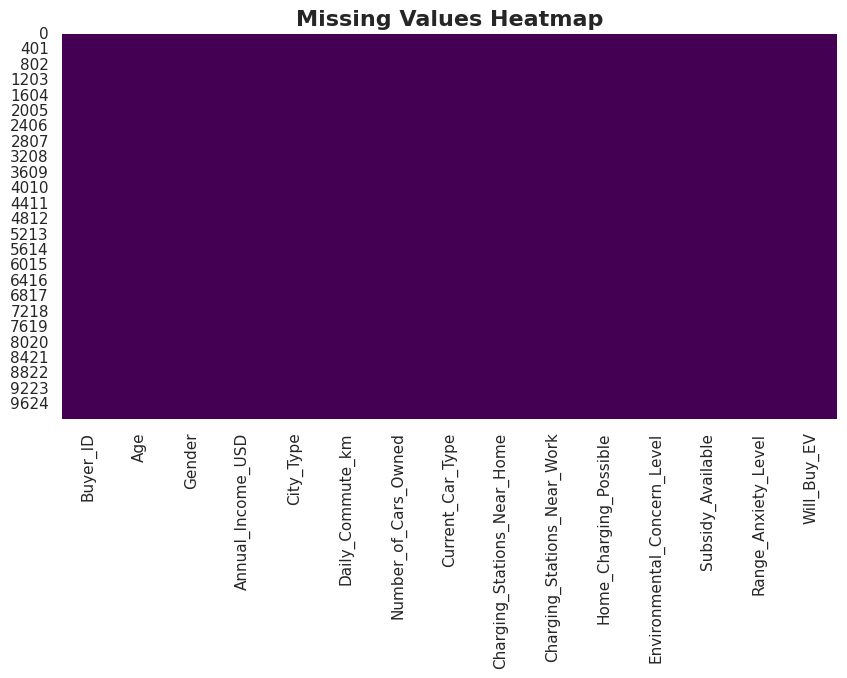

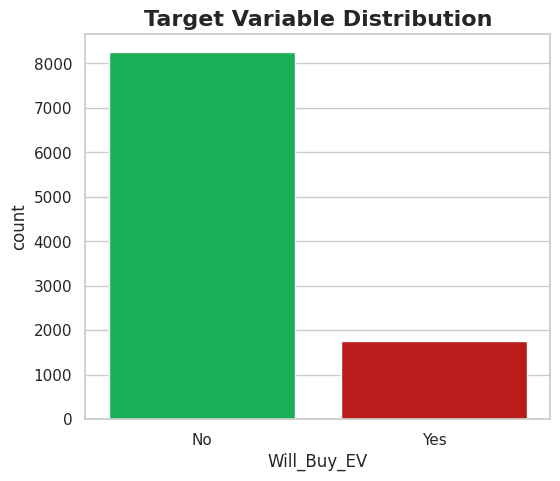

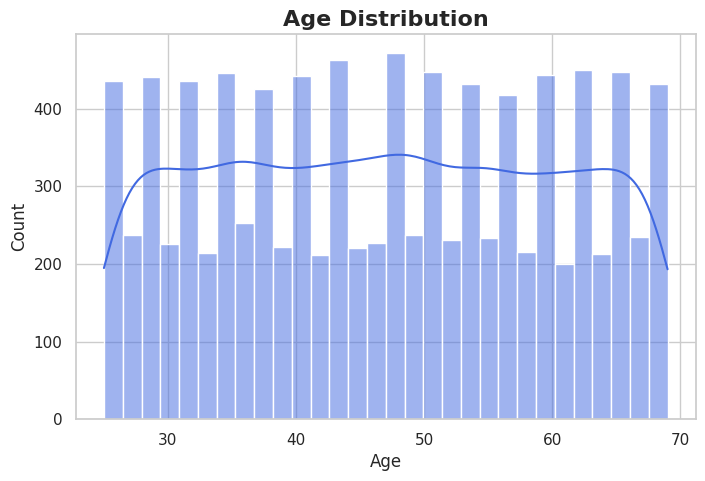

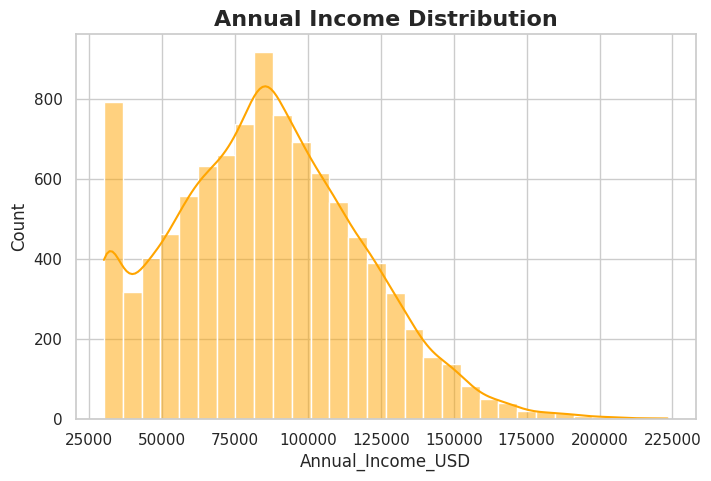

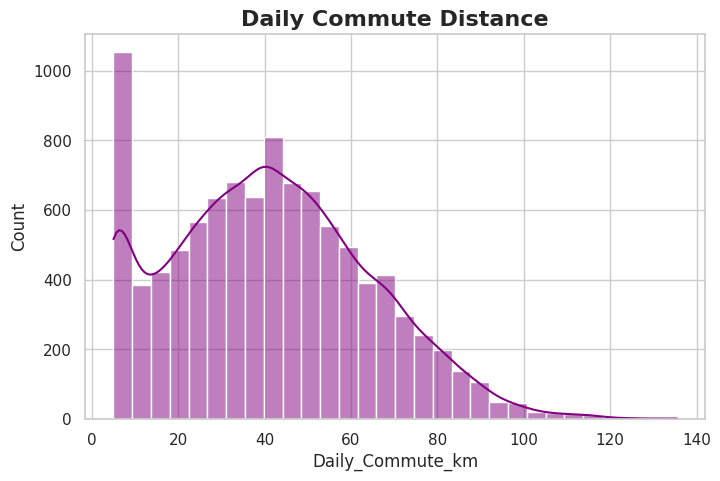

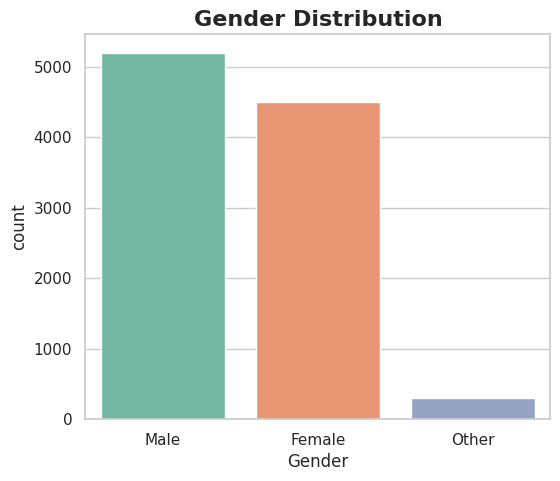

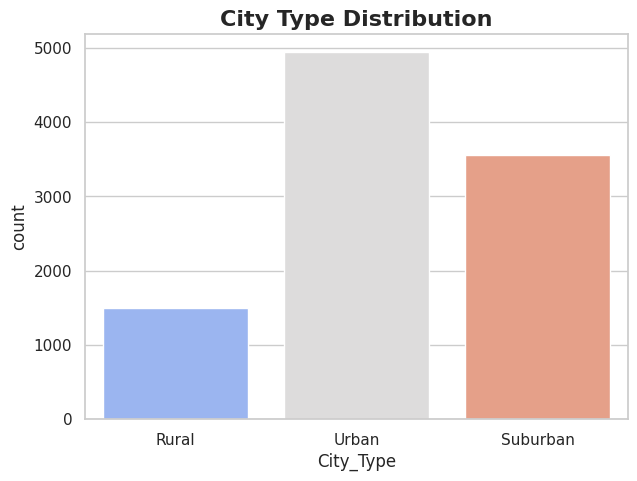

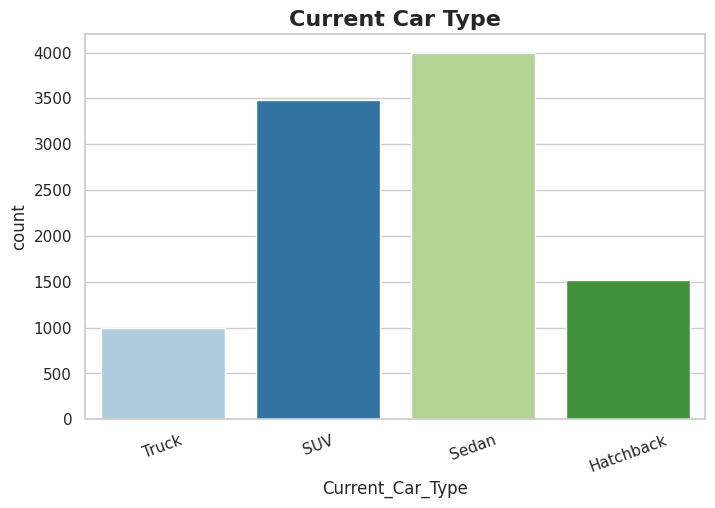

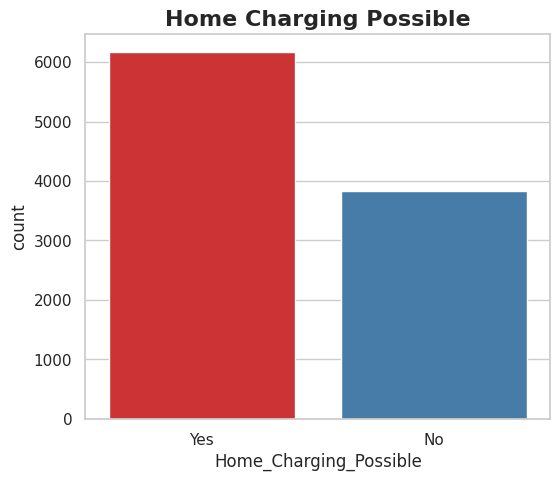

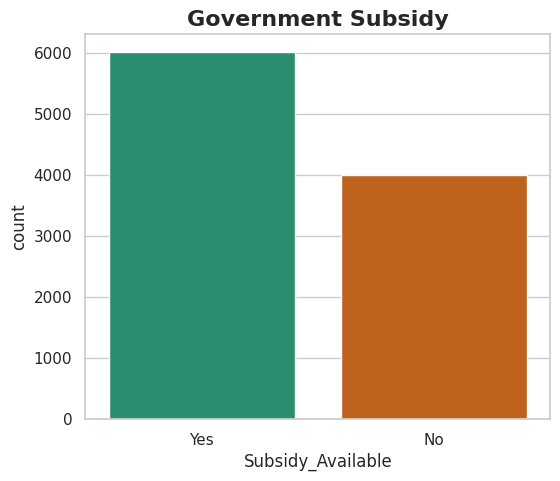

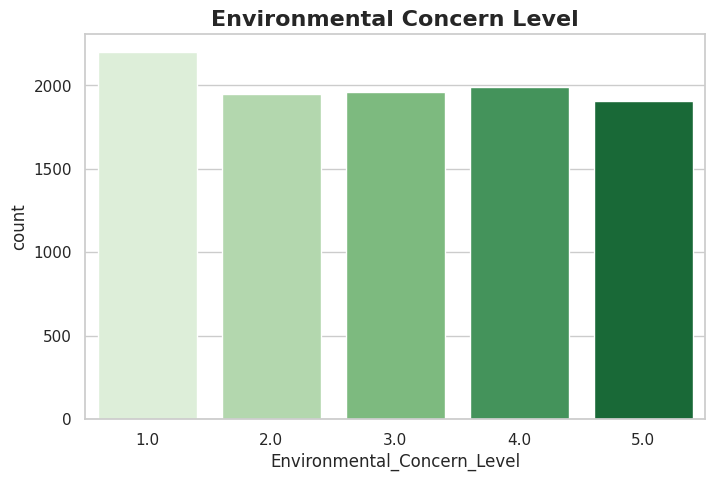

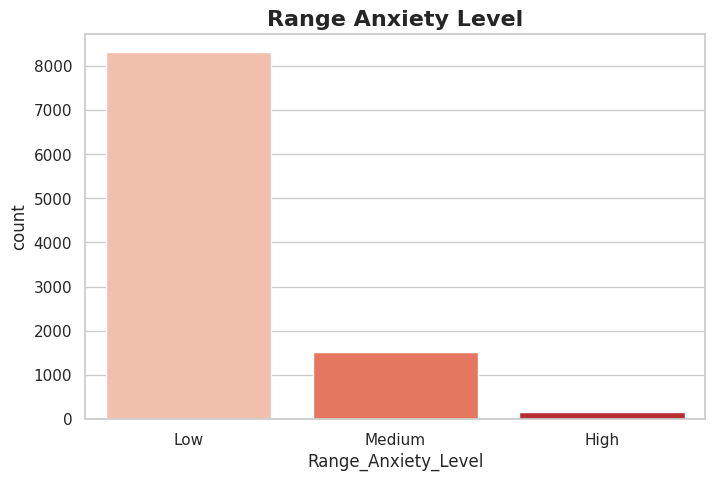

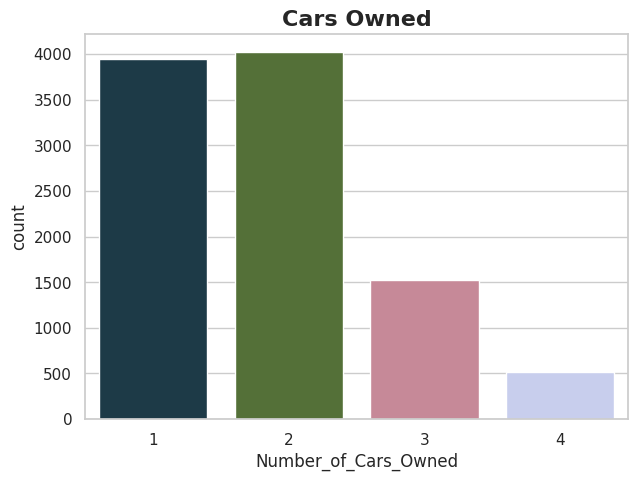

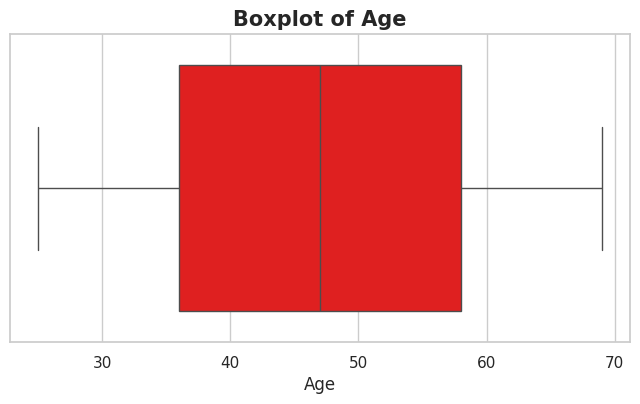

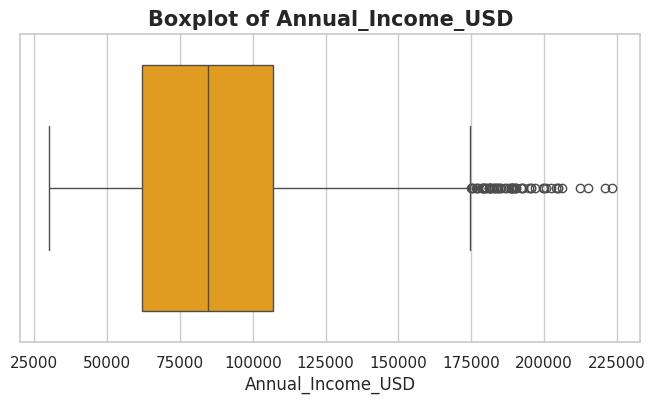

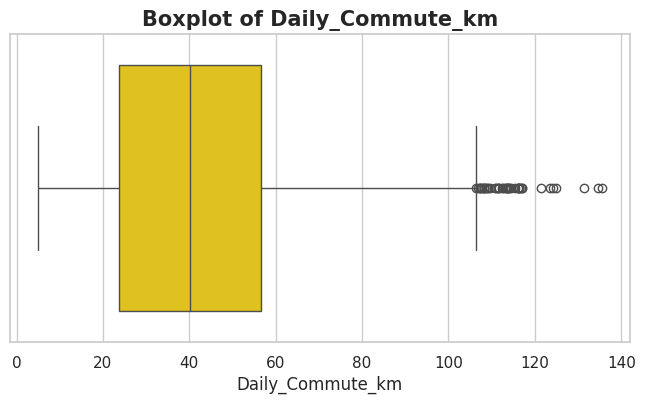

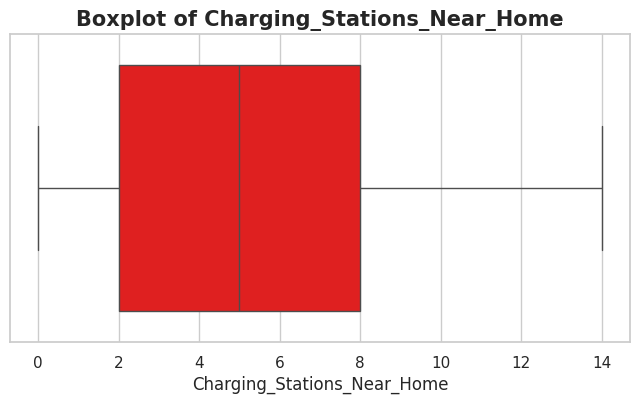

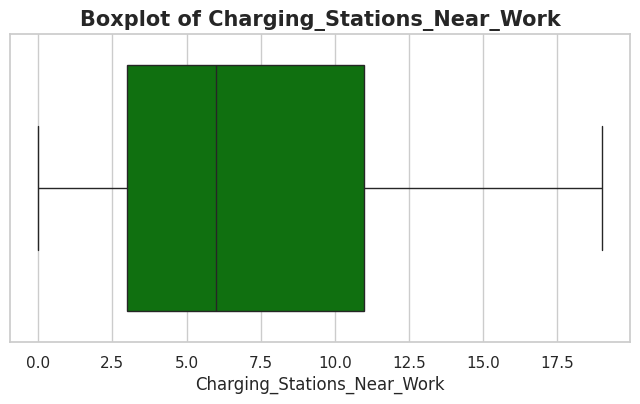

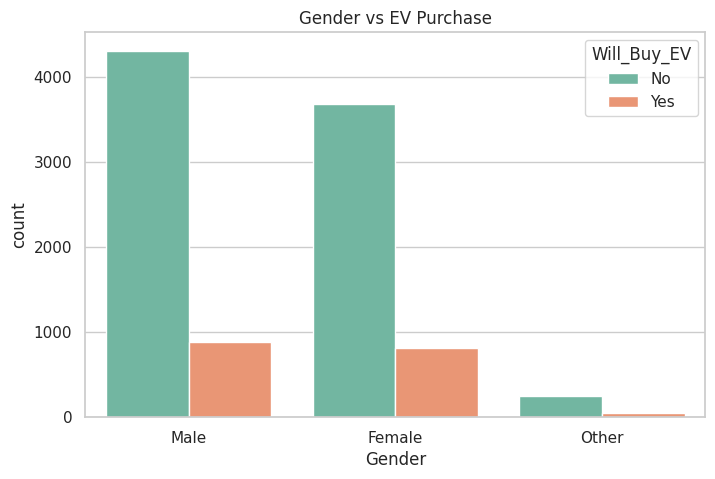

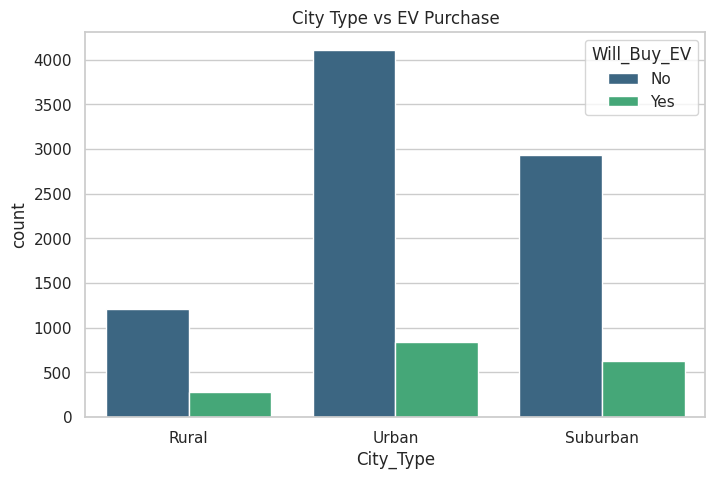

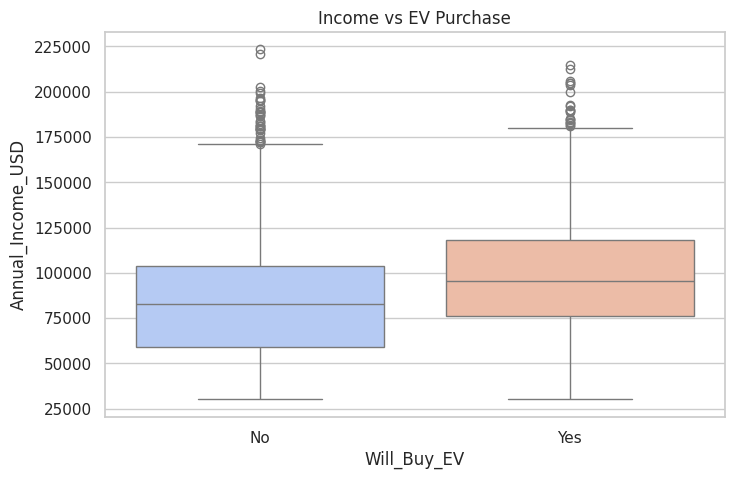

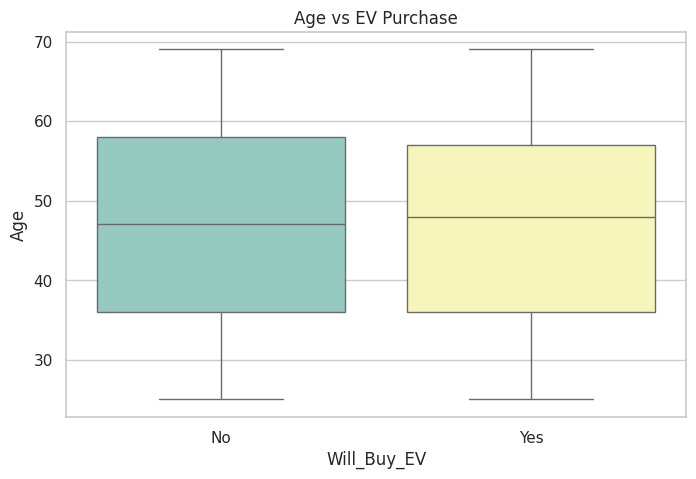

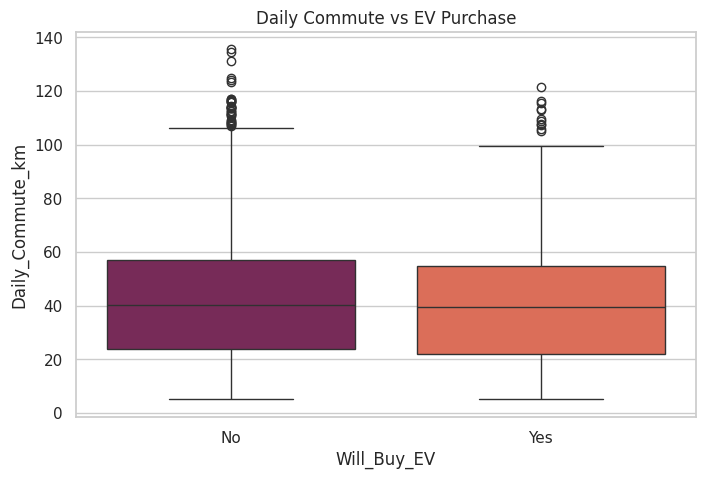

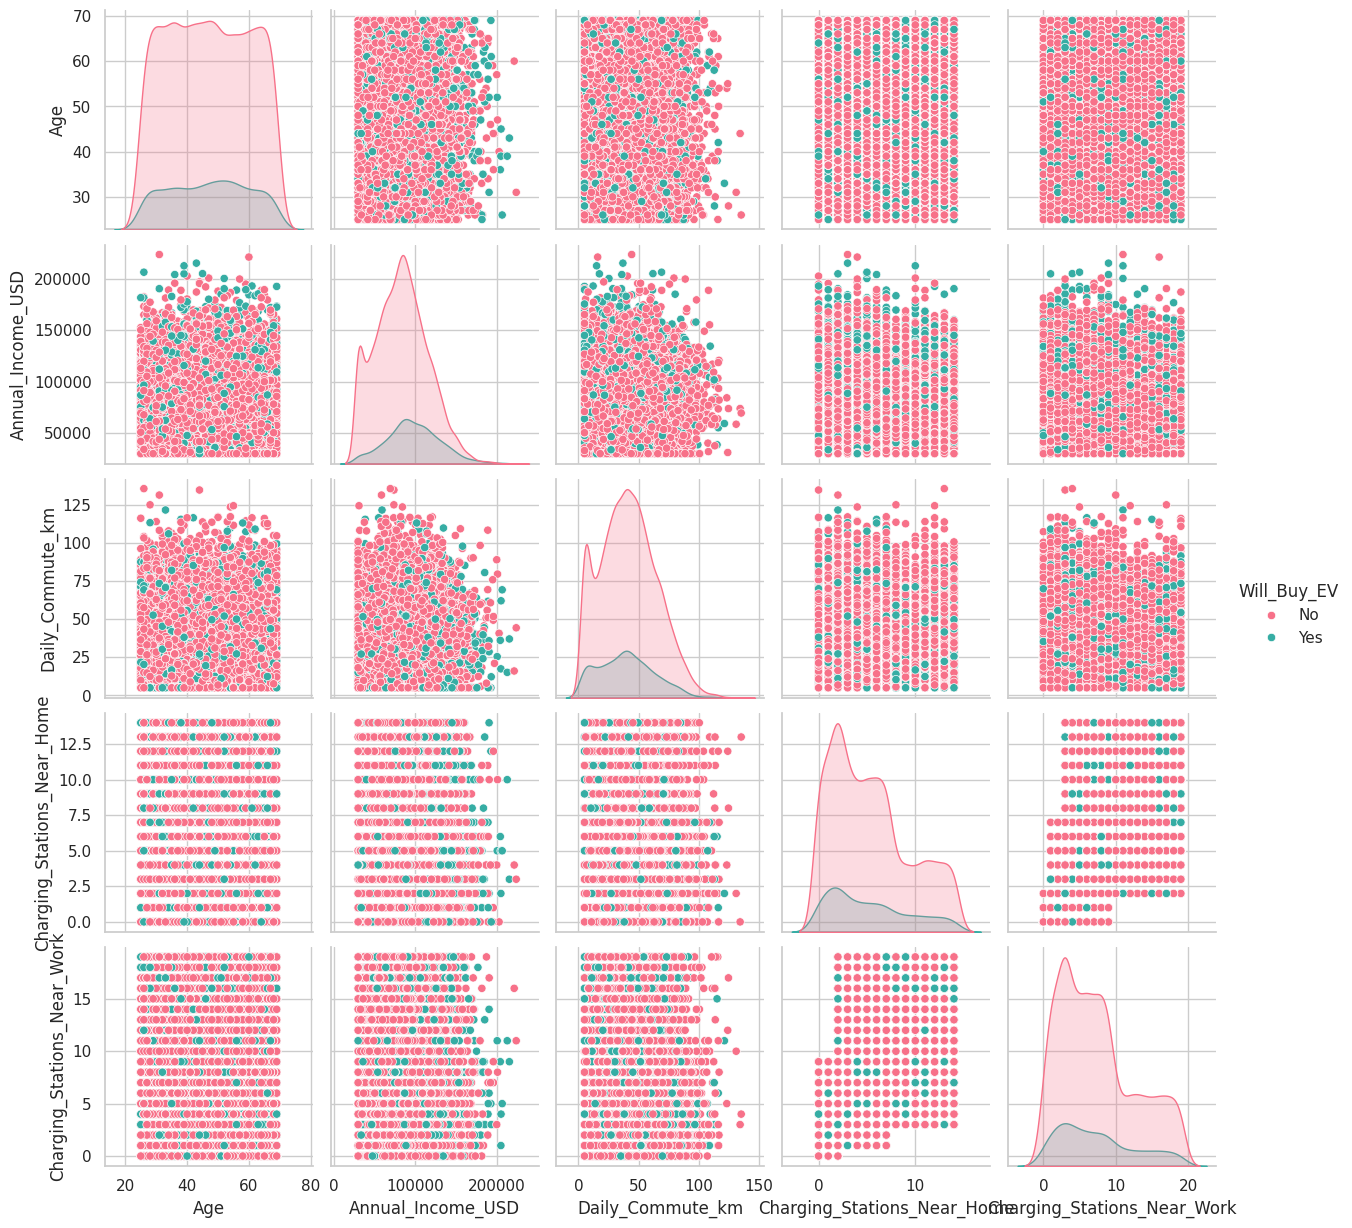

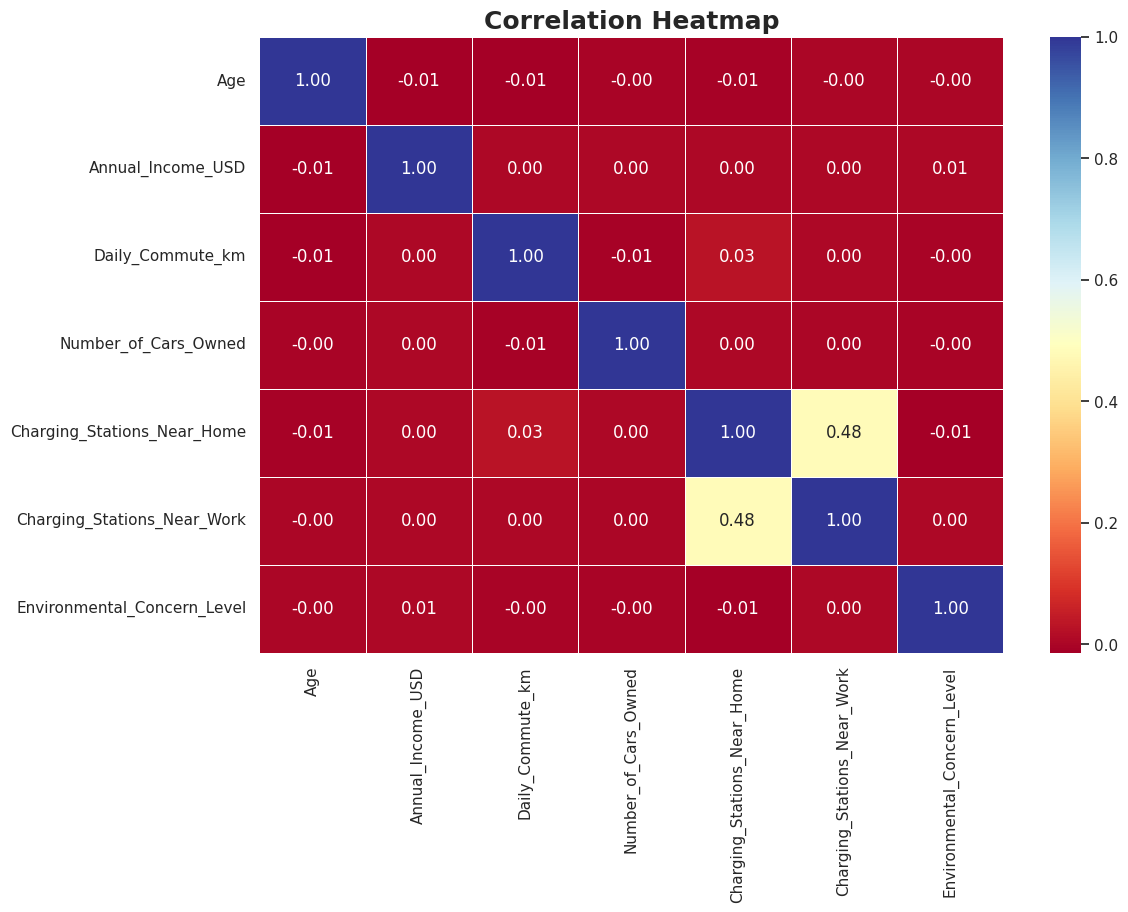

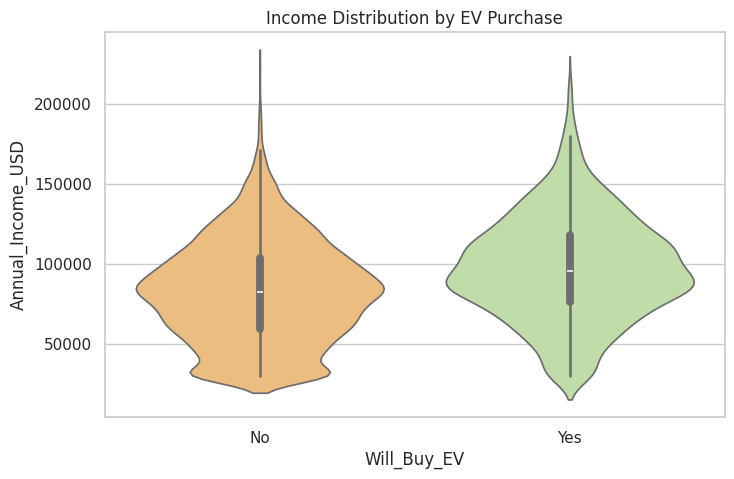

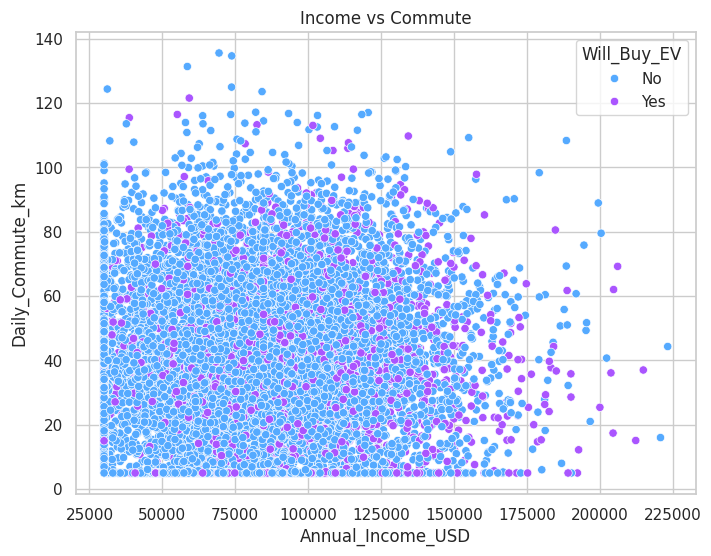

Visualization Completed Successfully


In [12]:
# ============================================================
# EV BUYERS DATASET - COMPLETE VISUALIZATION (EDA)
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# Load Dataset
# ------------------------------------------------------------


# ------------------------------------------------------------
# Plot Style
# ------------------------------------------------------------

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

# ============================================================
# BASIC INFORMATION
# ============================================================

print("="*60)
print("Shape :", df.shape)
print("="*60)

print(df.head())

print("="*60)
print(df.info())

print("="*60)
print(df.describe(include='all'))

# ============================================================
# Missing Values
# ============================================================

plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(),
            cbar=False,
            cmap="viridis")
plt.title("Missing Values Heatmap",
          fontsize=16,
          fontweight='bold')
plt.show()

# ============================================================
# Target Variable Distribution
# ============================================================

plt.figure(figsize=(6,5))

colors=['#00C853','#D50000']

sns.countplot(
    x='Will_Buy_EV',
    data=df,
    palette=colors
)

plt.title("Target Variable Distribution",
          fontsize=16,
          fontweight='bold')

plt.show()

# ============================================================
# Age Distribution
# ============================================================

plt.figure(figsize=(8,5))

sns.histplot(
    df['Age'],
    bins=30,
    kde=True,
    color='royalblue'
)

plt.title("Age Distribution",
          fontsize=16,
          fontweight='bold')

plt.show()

# ============================================================
# Income Distribution
# ============================================================

plt.figure(figsize=(8,5))

sns.histplot(
    df['Annual_Income_USD'],
    bins=30,
    kde=True,
    color='orange'
)

plt.title("Annual Income Distribution",
          fontsize=16,
          fontweight='bold')

plt.show()

# ============================================================
# Commute Distance
# ============================================================

plt.figure(figsize=(8,5))

sns.histplot(
    df['Daily_Commute_km'],
    bins=30,
    kde=True,
    color='purple'
)

plt.title("Daily Commute Distance",
          fontsize=16,
          fontweight='bold')

plt.show()

# ============================================================
# Gender
# ============================================================

plt.figure(figsize=(6,5))

sns.countplot(
    x='Gender',
    data=df,
    palette='Set2'
)

plt.title("Gender Distribution",
          fontsize=16,
          fontweight='bold')

plt.show()

# ============================================================
# City Type
# ============================================================

plt.figure(figsize=(7,5))

sns.countplot(
    x='City_Type',
    data=df,
    palette='coolwarm'
)

plt.title("City Type Distribution",
          fontsize=16,
          fontweight='bold')

plt.show()

# ============================================================
# Current Car Type
# ============================================================

plt.figure(figsize=(8,5))

sns.countplot(
    x='Current_Car_Type',
    data=df,
    palette='Paired'
)

plt.xticks(rotation=20)

plt.title("Current Car Type",
          fontsize=16,
          fontweight='bold')

plt.show()

# ============================================================
# Home Charging Possible
# ============================================================

plt.figure(figsize=(6,5))

sns.countplot(
    x='Home_Charging_Possible',
    data=df,
    palette='Set1'
)

plt.title("Home Charging Possible",
          fontsize=16,
          fontweight='bold')

plt.show()

# ============================================================
# Subsidy Available
# ============================================================

plt.figure(figsize=(6,5))

sns.countplot(
    x='Subsidy_Available',
    data=df,
    palette='Dark2'
)

plt.title("Government Subsidy",
          fontsize=16,
          fontweight='bold')

plt.show()

# ============================================================
# Environmental Concern
# ============================================================

plt.figure(figsize=(8,5))

sns.countplot(
    x='Environmental_Concern_Level',
    data=df,
    palette='Greens'
)

plt.title("Environmental Concern Level",
          fontsize=16,
          fontweight='bold')

plt.show()

# ============================================================
# Range Anxiety
# ============================================================

plt.figure(figsize=(8,5))

sns.countplot(
    x='Range_Anxiety_Level',
    data=df,
    palette='Reds'
)

plt.title("Range Anxiety Level",
          fontsize=16,
          fontweight='bold')

plt.show()

# ============================================================
# Number of Cars Owned
# ============================================================

plt.figure(figsize=(7,5))

sns.countplot(
    x='Number_of_Cars_Owned',
    data=df,
    palette='cubehelix'
)

plt.title("Cars Owned",
          fontsize=16,
          fontweight='bold')

plt.show()

# ============================================================
# Boxplots
# ============================================================

num_cols=[
'Age',
'Annual_Income_USD',
'Daily_Commute_km',
'Charging_Stations_Near_Home',
'Charging_Stations_Near_Work'
]

for col in num_cols:

    plt.figure(figsize=(8,4))

    sns.boxplot(
        x=df[col],
        color=np.random.choice([
            'skyblue',
            'orange',
            'green',
            'red',
            'violet',
            'gold'
        ])
    )

    plt.title(f"Boxplot of {col}",
              fontsize=15,
              fontweight='bold')

    plt.show()

# ============================================================
# Target vs Gender
# ============================================================

plt.figure(figsize=(8,5))

sns.countplot(
    x='Gender',
    hue='Will_Buy_EV',
    data=df,
    palette='Set2'
)

plt.title("Gender vs EV Purchase")

plt.show()

# ============================================================
# Target vs City Type
# ============================================================

plt.figure(figsize=(8,5))

sns.countplot(
    x='City_Type',
    hue='Will_Buy_EV',
    data=df,
    palette='viridis'
)

plt.title("City Type vs EV Purchase")

plt.show()

# ============================================================
# Income vs EV Purchase
# ============================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Will_Buy_EV',
    y='Annual_Income_USD',
    data=df,
    palette='coolwarm'
)

plt.title("Income vs EV Purchase")

plt.show()

# ============================================================
# Age vs EV Purchase
# ============================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Will_Buy_EV',
    y='Age',
    data=df,
    palette='Set3'
)

plt.title("Age vs EV Purchase")

plt.show()

# ============================================================
# Commute vs EV Purchase
# ============================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Will_Buy_EV',
    y='Daily_Commute_km',
    data=df,
    palette='rocket'
)

plt.title("Daily Commute vs EV Purchase")

plt.show()

# ============================================================
# Pairplot
# ============================================================

sns.pairplot(
    df[
        [
            'Age',
            'Annual_Income_USD',
            'Daily_Commute_km',
            'Charging_Stations_Near_Home',
            'Charging_Stations_Near_Work',
            'Will_Buy_EV'
        ]
    ],
    hue='Will_Buy_EV',
    palette='husl'
)

plt.show()

# ============================================================
# Correlation Heatmap
# ============================================================

numeric=df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap='RdYlBu',
    linewidths=.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap",
          fontsize=18,
          fontweight='bold')

plt.show()

# ============================================================
# Violin Plot
# ============================================================

plt.figure(figsize=(8,5))

sns.violinplot(
    x='Will_Buy_EV',
    y='Annual_Income_USD',
    data=df,
    palette='Spectral'
)

plt.title("Income Distribution by EV Purchase")

plt.show()

# ============================================================
# Scatter Plot
# ============================================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Annual_Income_USD',
    y='Daily_Commute_km',
    hue='Will_Buy_EV',
    data=df,
    palette='cool'
)

plt.title("Income vs Commute")

plt.show()

print("="*60)
print("Visualization Completed Successfully")
print("="*60)

In [13]:
# ============================================================
# PART 2 : FEATURE ENGINEERING (UPDATED & ERROR FREE)
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ============================================================
# Copy Dataset
# ============================================================

data = df.copy()

print("=" * 60)
print("Original Shape :", data.shape)
print("=" * 60)

# ============================================================
# Remove Duplicate Rows
# ============================================================

print("Duplicate Rows :", data.duplicated().sum())

data.drop_duplicates(inplace=True)

# ============================================================
# Remove Buyer_ID
# ============================================================

if "Buyer_ID" in data.columns:
    data.drop("Buyer_ID", axis=1, inplace=True)

# ============================================================
# Missing Values
# ============================================================

num_cols = data.select_dtypes(include=np.number).columns.tolist()
cat_cols = data.select_dtypes(include="object").columns.tolist()

for col in num_cols:
    data[col] = data[col].fillna(data[col].median())

for col in cat_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

# ============================================================
# Encode Target First
# ============================================================

target = "Will_Buy_EV"

target_encoder = None

if data[target].dtype == "object":
    target_encoder = LabelEncoder()
    data[target] = target_encoder.fit_transform(data[target])

# ============================================================
# Encode Remaining Categorical Columns
# ============================================================

label_encoders = {}

categorical_columns = [
    col for col in data.select_dtypes(include="object").columns
    if col != target
]

for col in categorical_columns:

    le = LabelEncoder()

    data[col] = le.fit_transform(data[col].astype(str))

    label_encoders[col] = le

print("\nCategorical Encoding Completed")

# ============================================================
# Outlier Treatment
# ============================================================

numeric_cols = data.select_dtypes(include=np.number).columns.tolist()

numeric_cols.remove(target)

for col in numeric_cols:

    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    data[col] = np.clip(data[col], lower, upper)

print("Outliers Treated")

# ============================================================
# Feature Engineering
# ============================================================

# Total Charging Stations

data["Total_Charging_Stations"] = (
    data["Charging_Stations_Near_Home"] +
    data["Charging_Stations_Near_Work"]
)

# Income Per Car

data["Income_Per_Car"] = (
    data["Annual_Income_USD"] /
    (data["Number_of_Cars_Owned"] + 1)
)

# Long Commute

data["Long_Commute"] = (
    data["Daily_Commute_km"] >=
    data["Daily_Commute_km"].median()
).astype(int)

# High Environmental Concern

data["High_Environment"] = (
    data["Environmental_Concern_Level"] >=
    data["Environmental_Concern_Level"].median()
).astype(int)

# High Range Anxiety

data["High_Range_Anxiety"] = (
    data["Range_Anxiety_Level"] >=
    data["Range_Anxiety_Level"].median()
).astype(int)

# Home Charging

data["Home_Charging"] = (
    data["Home_Charging_Possible"] > 0
).astype(int)

# Subsidy

data["Government_Support"] = (
    data["Subsidy_Available"] > 0
).astype(int)

# Charging Access

data["Charging_Access"] = (
    data["Charging_Stations_Near_Home"] * 0.6 +
    data["Charging_Stations_Near_Work"] * 0.4
)

# Income × Environment

data["Income_Environment"] = (
    data["Annual_Income_USD"] *
    (data["Environmental_Concern_Level"] + 1)
)

# Commute × Range Anxiety

data["Commute_Range"] = (
    data["Daily_Commute_km"] *
    (data["Range_Anxiety_Level"] + 1)
)

# ============================================================
# Split Features & Target
# ============================================================

X = data.drop(columns=[target])

y = data[target]

print("\nFeatures :", X.shape)
print("Target :", y.shape)

# ============================================================
# Train Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTrain :", X_train.shape)
print("Test :", X_test.shape)

# ============================================================
# Feature Scaling
# ============================================================

scaler = StandardScaler()

numeric_features = X_train.select_dtypes(include=np.number).columns

X_train[numeric_features] = scaler.fit_transform(
    X_train[numeric_features]
)

X_test[numeric_features] = scaler.transform(
    X_test[numeric_features]
)

print("\nScaling Completed")

# ============================================================
# Feature Information
# ============================================================

print("=" * 60)
print("Total Features :", len(X.columns))
print("=" * 60)

for i, col in enumerate(X.columns, 1):
    print(f"{i}. {col}")

# ============================================================
# Save Engineered Dataset
# ============================================================

engineered_dataset = pd.concat(
    [X, pd.Series(y, name=target)],
    axis=1
)

engineered_dataset.to_csv(
    "engineered_ev_dataset.csv",
    index=False
)

print("\nEngineered Dataset Saved Successfully")
print("=" * 60)
print("FEATURE ENGINEERING COMPLETED")
print("=" * 60)

Original Shape : (10000, 15)
Duplicate Rows : 0

Categorical Encoding Completed
Outliers Treated

Features : (10000, 23)
Target : (10000,)

Train : (8000, 23)
Test : (2000, 23)

Scaling Completed
Total Features : 23
1. Age
2. Gender
3. Annual_Income_USD
4. City_Type
5. Daily_Commute_km
6. Number_of_Cars_Owned
7. Current_Car_Type
8. Charging_Stations_Near_Home
9. Charging_Stations_Near_Work
10. Home_Charging_Possible
11. Environmental_Concern_Level
12. Subsidy_Available
13. Range_Anxiety_Level
14. Total_Charging_Stations
15. Income_Per_Car
16. Long_Commute
17. High_Environment
18. High_Range_Anxiety
19. Home_Charging
20. Government_Support
21. Charging_Access
22. Income_Environment
23. Commute_Range

Engineered Dataset Saved Successfully
FEATURE ENGINEERING COMPLETED


## Features Engineering 

Training Models...

Logistic Regression

Decision Tree

Random Forest

Extra Trees

Gradient Boosting

AdaBoost

Support Vector Machine

KNN

Gaussian NB

MLP

LDA

QDA

XGBoost
                     Model  Accuracy  Precision  Recall  F1 Score   ROC AUC  \
0      Logistic Regression    0.8800   0.871848  0.8800  0.873678  0.903538   
4        Gradient Boosting    0.8775   0.869536  0.8775  0.871694  0.902779   
6   Support Vector Machine    0.8745   0.863770  0.8745  0.864056  0.861519   
10                     LDA    0.8740   0.863248  0.8740  0.863848  0.891623   
5                 AdaBoost    0.8715   0.869675  0.8715  0.870536  0.898226   
2            Random Forest    0.8645   0.852625  0.8645  0.855088  0.885694   
3              Extra Trees    0.8630   0.851964  0.8630  0.854930  0.885568   
12                 XGBoost    0.8580   0.848700  0.8580  0.852001  0.875370   
9                      MLP    0.8480   0.835587  0.8480  0.839759  0.861345   
7                      KNN    0.

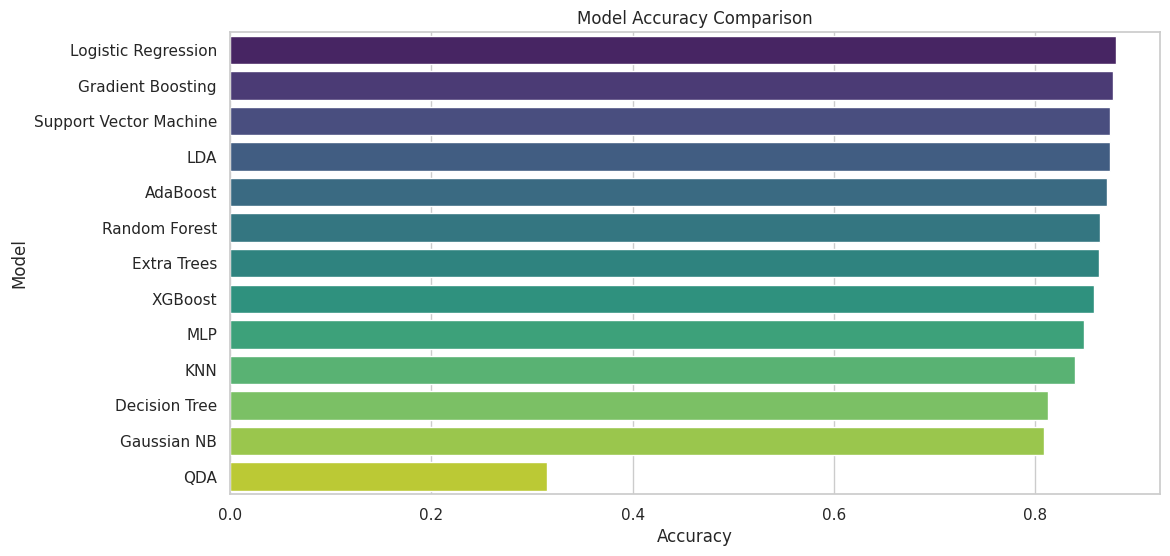


Best Model : Logistic Regression


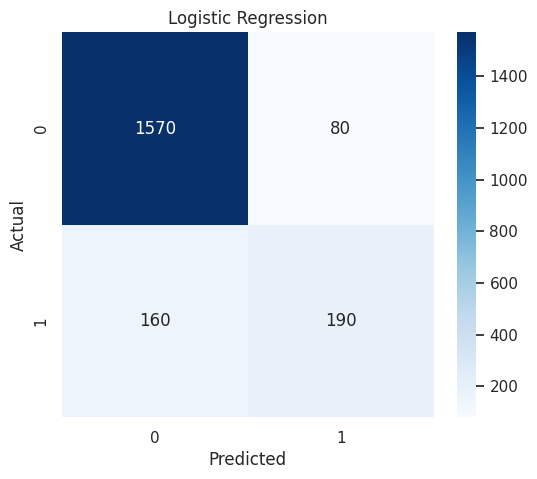

              precision    recall  f1-score   support

           0       0.91      0.95      0.93      1650
           1       0.70      0.54      0.61       350

    accuracy                           0.88      2000
   macro avg       0.81      0.75      0.77      2000
weighted avg       0.87      0.88      0.87      2000



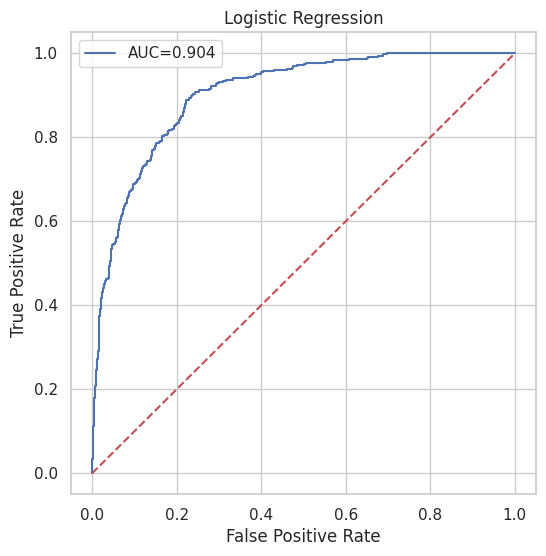


Model Comparison Saved.
Machine Learning Pipeline Completed Successfully


In [14]:
# ============================================================
# PART 3 : MACHINE LEARNING MODELS
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from sklearn.model_selection import cross_val_score

# ============================================================
# Import ML Models
# ============================================================

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)

from sklearn.svm import SVC

from sklearn.neighbors import KNeighborsClassifier

from sklearn.naive_bayes import GaussianNB

from sklearn.neural_network import MLPClassifier

from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis,
    QuadraticDiscriminantAnalysis
)

# Optional XGBoost

try:
    from xgboost import XGBClassifier
    xgb_available = True
except:
    xgb_available = False

# ============================================================
# Models Dictionary
# ============================================================

models = {

    "Logistic Regression":
        LogisticRegression(max_iter=500),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(random_state=42),

    "Extra Trees":
        ExtraTreesClassifier(random_state=42),

    "Gradient Boosting":
        GradientBoostingClassifier(random_state=42),

    "AdaBoost":
        AdaBoostClassifier(random_state=42),

    "Support Vector Machine":
        SVC(probability=True, random_state=42),

    "KNN":
        KNeighborsClassifier(),

    "Gaussian NB":
        GaussianNB(),

    "MLP":
        MLPClassifier(max_iter=500, random_state=42),

    "LDA":
        LinearDiscriminantAnalysis(),

    "QDA":
        QuadraticDiscriminantAnalysis()

}

if xgb_available:
    models["XGBoost"] = XGBClassifier(
        eval_metric="logloss",
        random_state=42
    )

# ============================================================
# Train Models
# ============================================================

results = []

print("="*80)
print("Training Models...")
print("="*80)

for name, model in models.items():

    print(f"\n{name}")

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, pred)

    precision = precision_score(
        y_test,
        pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        pred,
        average="weighted",
        zero_division=0
    )

    try:
        probability = model.predict_proba(X_test)[:,1]

        auc = roc_auc_score(
            y_test,
            probability
        )

    except:

        auc = np.nan

    cv = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    ).mean()

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        auc,
        cv
    ])

# ============================================================
# Results Table
# ============================================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC",
        "CV Accuracy"
    ]
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

print(results_df)

# ============================================================
# Accuracy Plot
# ============================================================

plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x="Accuracy",
    y="Model",
    palette="viridis"
)

plt.title("Model Accuracy Comparison")

plt.show()

# ============================================================
# Best Model
# ============================================================

best_model_name = results_df.iloc[0]["Model"]

best_model = models[best_model_name]

print("\nBest Model :", best_model_name)

# ============================================================
# Confusion Matrix
# ============================================================

prediction = best_model.predict(X_test)

cm = confusion_matrix(
    y_test,
    prediction
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(best_model_name)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# ============================================================
# Classification Report
# ============================================================

print(classification_report(
    y_test,
    prediction
))

# ============================================================
# ROC Curve
# ============================================================

try:

    probability = best_model.predict_proba(X_test)[:,1]

    fpr, tpr, threshold = roc_curve(
        y_test,
        probability
    )

    plt.figure(figsize=(6,6))

    plt.plot(
        fpr,
        tpr,
        label=f"AUC={roc_auc_score(y_test, probability):.3f}"
    )

    plt.plot([0,1],[0,1],'r--')

    plt.xlabel("False Positive Rate")

    plt.ylabel("True Positive Rate")

    plt.title(best_model_name)

    plt.legend()

    plt.show()

except:

    print("ROC Curve not available.")

# ============================================================
# Feature Importance
# ============================================================

if hasattr(best_model, "feature_importances_"):

    importance = pd.DataFrame({

        "Feature":X.columns,

        "Importance":best_model.feature_importances_

    })

    importance = importance.sort_values(
        by="Importance",
        ascending=False
    )

    plt.figure(figsize=(10,8))

    sns.barplot(
        data=importance.head(20),
        x="Importance",
        y="Feature",
        palette="magma"
    )

    plt.title("Top 20 Important Features")

    plt.show()

# ============================================================
# Save Results
# ============================================================

results_df.to_csv(
    "Model_Comparison.csv",
    index=False
)

print("\nModel Comparison Saved.")

print("="*80)
print("Machine Learning Pipeline Completed Successfully")
print("="*80)

## Thanks.......Please Upvote